# **Question 1:**

**A. What visit types are most common for thyroid-related care?**

**B. Are certain thyroid diagnosis more likely to appear in specific visit types?**

## Python Script 1: Importing the Required Data

**Decision Process:**
- `import pandas as pd` = imports pandas library to notebook
- `measurements_timeseries` = variable used to reference our `measurements_analysis_ready.csv`
- `visit_thyroid` = variable name used to reference our `visit_analysis_ready.csv`
- `thyroid_testing` = variable name used to reference our `thyroid_testing_cohort.csv`
- `visits_thyroid.head()` = code used to confirm that our data imported correctly by visualizing the first 5 rows of data
- `visits_thyroid.columns` = code used to verify all columns imported correctly
- `len(visits_thyroid)` = code used to verify the total amount of rows present in the csv file (`visit_analysis_ready.csv`)

In [1]:
import pandas as pd

In [2]:
measurements_timeseries = pd.read_csv("measurements_analysis_ready.csv")
visits_thyroid = pd.read_csv("visits_analysis_ready.csv")
thyroid_testing = pd.read_csv("thyroid_testing_cohort.csv")

In [3]:
visits_thyroid.head()

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


In [4]:
visits_thyroid.columns

Index(['person_id', 'gender_concept_id', 'gender', 'gender_clean',
       'year_of_birth', 'age_at_visit', 'age_group', 'race', 'race_clean',
       'ethnicity', 'ethnicity_clean', 'snomed_condition_concept_id',
       'condition_description', 'condition_description_clean',
       'visit_concept_id', 'visit_type', 'visit_type_clean',
       'visit_type_group', 'visit_start_date', 'visit_end_date',
       'visit_duration_days', 'same_day_visit_flag', 'long_visit_flag_7d',
       'long_visit_flag_30d', 'office_related_flag', 'inpatient_related_flag',
       'emergency_related_flag', 'telehealth_flag'],
      dtype='str')

In [5]:
len(visits_thyroid)

179124

## **Question 1A: What visit types are most common for thyroid-related care?**
- In this analysis, we will be using 1 main csv file: `visits_analysis_ready.csv` (visits_thyroid)

## Python Script 2:
- This script provides which visit types are the most common from the thryoid population

**Decision Process:**
- `visit_type_count` = variable used to reference the total counts for each visit type
- `str.lower` = method used to convert all strings to lowercase in order to ensure that all visit types are counted regardless if they're capital or lowercase
- `str.strip()` = method used to ignore all leading and trailing spaces to ensure all visit types are counted
- `value_counts()` = method used to count the frequency of unique values 

In [6]:
visit_type_count = visits_thyroid["visit_type_group"].str.lower().str.strip().value_counts()
print(visit_type_count)

visit_type_group
office/outpatient    132319
emergency-related     23120
inpatient-related     11533
telehealth             6117
case management        6035
Name: count, dtype: int64


## Python Script 3:

- This script takes the previous data (total counts for each visit type), and converts it into a table that has columns `Visit Type` and `Count`

**Decision Process:**
- `visit_types_table` = variable used to reference the 'Visits Type" table created
- `visit_type_count`= variable used to reference the total counts for each visit type
- `reset_index()` = method that resets df to a new integer index starting from 0
- `.columns` = sets the column names

In [7]:
visit_types_table = visit_type_count.reset_index()
visit_types_table.columns = ["Visit Type", "Count"]

In [8]:
print(visit_types_table)

          Visit Type   Count
0  office/outpatient  132319
1  emergency-related   23120
2  inpatient-related   11533
3         telehealth    6117
4    case management    6035


## Python Script 4:
- This script converts the "Visits Type" original table into a table that converts the data into percentages rounded by 2 decimals for each visit type
- We use a mathematical formula: (count/ total) * 100 
    - this formula provides the percentages for each visit type

**Decision Process:**
- `visit_types_table` = variable used to reference the "Visits Type" table created
- `.sum()` = returns total sum of numeric values
- `* 100` = multiplies number by 100
- `.round()` = rounds number to a specific number of decimal places
- `/` = division
- `print()` = displays data

In [9]:
visit_types_table["Percent"] = (visit_types_table["Count"] / visit_types_table["Count"].sum() * 100).round(2)
print(visit_types_table)

          Visit Type   Count  Percent
0  office/outpatient  132319    73.87
1  emergency-related   23120    12.91
2  inpatient-related   11533     6.44
3         telehealth    6117     3.41
4    case management    6035     3.37


## Matplotlib: Most Common Visit Types for Thyroid-Related Care Bar Graph
- We used matplotlib to plot the desired data
- We'll plot:
    - A bar graph of the most common visit types for thyroid-related care

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

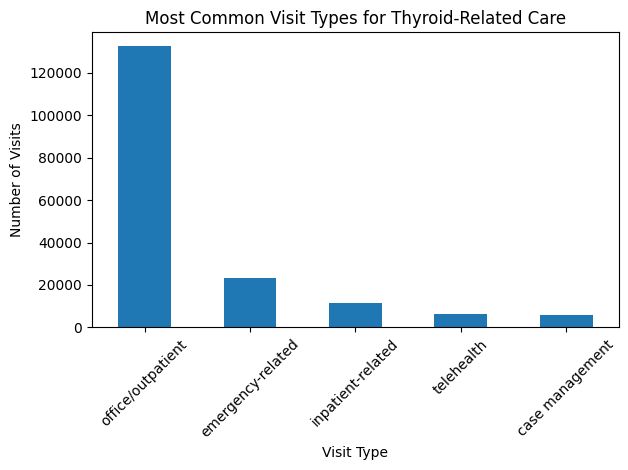

In [11]:
visit_type_count.plot(kind = "bar")

plt.title("Most Common Visit Types for Thyroid-Related Care")
plt.xlabel("Visit Type")
plt.ylabel("Number of Visits")

plt.xticks(rotation = 45)
plt.tight_layout()

plt.savefig("visits_type.png")
plt.show()

## **Narrative for Question 1A: What visit types are most common for thyroid-related care?**

### Objective:
- Find which visit types are most common for our thyroid-related patient population

### CSV files used:
- Only used 1 main csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Figure out the total counts for each visit type
2. Take the data obtained from step 1 and convert it into a more organized and cleaner table 
3. Convert the original table (from step 2) into a percentage table
4. Create a bar graph to visualize the data

### Findings:
After figuring out the total number of thyroid-related patient cases per visit type, we discovered that there are 5 main visit types:
1. office/outpatient
2. emergency-related
3. inpatient-related
4. telehealth
5. case management

From these 5 main visit types, based on the data gathered, we can conclude that "office/outpatient" is the visit type with the most cases seen with a total of 132,319 cases. Essentially the top 3 most common visit types for thyroid-related care are:
1. office/outpatient (132,319 total)
2. emergency-related (23,120 total)
3. inpatient-related (11,533 total)

From the percent table, we can conclude that "office/outpatient" visits make up around 74% of the total visit-types for thyroid-related care! While, "emergency-related" care make up around 13% of total visit types. Overall, we can conclude that the most common visit type for thyroid-related care are "office/outpatient" visits that make up a total of 74% of visits.

## **Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**
- In this analysis, we will be using 1 main csv file: `visits_analysis_ready.csv` (visits_thyroid)

## Python Script 1: Creating a Contingency Table
- This script provides information on the frequency of each thyroid-related diagnosis in each visit type

- We will be creating a contingency table with our 2 categorical variables involved that are:
    1. Our **"column"** variable = Visit Type = `visit_type_group_column`
    2. Our **"row"**  variable = Thyroid Diagnosis = `condition_description_clean`

**Decision Process:**
- `diagnosis_by_visit_type_counts` = variable used to reference our contingency table 
- `pd.crosstab()` = creates a contingency table
- `visit_thyroid` = variable name used to reference our `visit_analysis_ready.csv`
- `condition_description_clean` = cleaned condition_description column from `visit_thyroid`that references the various thyroid-related diagnosis
- `visit_type_group` = visit_type_group column from `visit_thyroid` that references that categories of visit types
- `print()` = displays data

In [12]:
diagnosis_by_visit_type_counts = pd.crosstab( 
    visits_thyroid["condition_description_clean"],
    visits_thyroid["visit_type_group"]
)

print(diagnosis_by_visit_type_counts)

visit_type_group             Case Management  Emergency-Related  \
condition_description_clean                                       
Disorder of thyroid gland                 61                320   
Hyperthyroidism                          694                791   
Hypothyroidism                          5280              22009   

visit_type_group             Inpatient-Related  Office/Outpatient  Telehealth  
condition_description_clean                                                    
Disorder of thyroid gland                  127               4162         137  
Hyperthyroidism                            300               7447         742  
Hypothyroidism                           11106             120710        5238  


## Python Script 2: Row proportions/distributions
- This script takes the contingency table information, on the frequency of each thyroid-related diagnosis in each visit type, and converts it into percentages to provide a visual on the distribution of thyroid diagnosis across various visit types
- This script will provide the percentages for the row variable, or in other words it will provide the row proportions specifically

- We will be creating a contingency table with our 2 categorical variables involved that are:
    1. Our **"column"** variable = Visit Type = `visit_type_group_column`
    2. Our **"row"**  variable = Thyroid Diagnosis = `condition_description_clean`

**Decision Process:**
- `diagnosis_by_visit_type_counts` = variable used to reference our contingency table 
- `pd.crosstab()` = creates a contingency table
- `visit_thyroid` = variable name used to reference our `visit_analysis_ready.csv`
- `condition_description_clean` = cleaned condition_description column from `visit_thyroid`that references the various thyroid-related diagnosis
- `visit_type_group` = visit_type_group column from `visit_thyroid` that references that categories of visit types
- `normalize = "index"` = divides all the values in each row by the sum of total row value
- `.round()` = rounds number to a specific number of decimal places
- `print()` = displays data

In [13]:
diagnosis_by_visit_type_percent = pd.crosstab(
    visits_thyroid["condition_description_clean"],
    visits_thyroid["visit_type_group"],
    normalize = "index"
) * 100

print(diagnosis_by_visit_type_percent.round(2))

visit_type_group             Case Management  Emergency-Related  \
condition_description_clean                                       
Disorder of thyroid gland               1.27               6.66   
Hyperthyroidism                         6.96               7.93   
Hypothyroidism                          3.21              13.39   

visit_type_group             Inpatient-Related  Office/Outpatient  Telehealth  
condition_description_clean                                                    
Disorder of thyroid gland                 2.64              86.58        2.85  
Hyperthyroidism                           3.01              74.66        7.44  
Hypothyroidism                            6.76              73.45        3.19  


## Seaborn: Visit Type Distribution by Thyroid Diagnosis Heatmap
- We used seaborn to plot the desired data
- We'll plot:
    - A heatmap of the visit type distributions by thyroid diagnosis heatmap

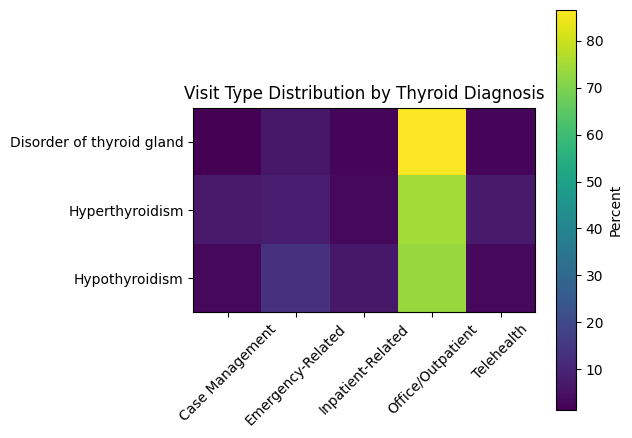

In [14]:
plt.imshow(diagnosis_by_visit_type_percent)
plt.colorbar(label = "Percent")

plt.xticks(
    range(len(diagnosis_by_visit_type_percent.columns)),
    diagnosis_by_visit_type_percent.columns,
    rotation = 45
)

plt.yticks(
    range(len(diagnosis_by_visit_type_percent.index)),
    diagnosis_by_visit_type_percent.index
)

plt.title("Visit Type Distribution by Thyroid Diagnosis")

plt.tight_layout()
plt.savefig("diagnosis_visit_types_heatmap.png")
plt.show()

## Matplotlib: Visit Type Distribution by Thyroid Diagnosis Bar Graph
- We used matplotlib to plot the desired data
- We'll plot:
    - A bar graph of the visit type distribution by thyroid diagnosis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
diagnosis_by_visit_type_percent.T.plot(kind = "bar")

plt.title("Visit Type Distribution by Thyroid Diagnosis")
plt.xlabel("Visit Type")
plt.ylabel("Percent")

plt.xticks(rotation = 45)
plt.legend(title = "Diagnosis")

plt.tight_layout()
plt.savefig("visit_type_by_diagnosis.png")
plt.show()

NameError: name 'diagnosis_by_visit_type_percent' is not defined

## **Narrative for Question 1B: Are certain thyroid diagnosis more likely to appear in specific visit types?**

### Objective:
- Find if there's specific thyroid diagnosis that are more likely to appear in specific visit types than others

### CSV files used:
- Only used 1 main csv file for this question: `visits_analysis_ready.csv`

### Approach Taken:
1. Create a contingency table to figure out the frequency of each thyroid-related diagnosis in each visit type
2. Convert the contingency table values to percentages (for the rows) in order to visualize the percent distribution of thyroid diagnosis across the various visit types
3. Create a Heatmap and a Bar Graph to properly visualize our findings

### Findings:

After crating a contingency table, we can see that a large portion of thyroid-related cases make up the "office/outpatient" visit type compared to the others. We can see that 87% of that visit type is the diagnosis for disroder of the thyroid gland, and hyperthyroidism and hypothyroidism have a similar frequency of 74% each. In addition, the "emergency-realted" visit types have a 13% Hypothyroidism rate than the other visit types. 

These results are further emphasized/validated in both the visit type distribution by thyroid diagnosis heatmap and bar graph. We can see that a large percent of thyroid diagnosis are made in "office/outpatient" care settings that is signified by a bright yellow color, and the most common diagnosis in this care setting is disorder of the thyroid gland. However, as stated before, both hyperthyroidism and hypothyroidism still have abnormally elevated percentages as well in the same care setting. (The lower percent areas are those in darker purple colors.) 

This heatmap suggests that most thyroid-related care happens more often in office/outpatient visits which can indicate that the diagnosis is frequently managed in this visit type. This can be due to the fact that most thyroid conditions are chronic but manageable if one is consistent with their treatment plans. Therefore, most thryoid-related care is not commonly diagnosed or treated in emergency and hospitilization related care. There is a slightly elevated percentage of hypothyroidism diagnosis that are seen in emergency-related settings and hyperthyroidism in telehealth. However, the percentage of these care settings are not as pronounced as the thyroid diagnosis in office/outpatient care. The same data is seen in the bar graph.